In [1]:
import pandas as pd #Used for data management
import numpy as np #Used for mathematical calculations
import matplotlib.pyplot as plt #Used for creating graphs
import seaborn as sns #Used for creating graphs
import geopandas as gpd #Used for creating map plots
import matplotlib.colors as mpc #Used for creating logarithmic scale
import matplotlib.patches as mpatches #Used for sorting of categorical data legends

In [2]:
svi_data = pd.read_csv('CIVE202_Project5_SVI_2022_US_county_Wiggins&Anciaux.csv') #Imports SVI data
fema_data = pd.read_csv('FEMA_HurricanePaths_US.csv') #Imports FEMA hurricane path data
tracts = gpd.read_file('nri_shape_file') #Imports NRI data with shapefile
states = gpd.read_file("cb_2024_us_state_500k.zip") #Imports US Census Bureau US state outline shapefile

In [3]:
tracts_clean = tracts.set_crs(epsg = 4326, inplace = True, allow_override = True) #Checks and sets projection

tracts_clean = tracts_clean.to_crs(epsg = 4326) #Changes CRS

tracts_clean = tracts_clean.replace(-9999, np.nan) #Replaces -9999 nulls with NaN

tracts_clean.crs = "EPSG:3857" #Changes projection

tracts_clean = tracts_clean.to_crs(epsg=4326) #Changes to degrees to match limits

tracts_clean = tracts_clean.to_crs("ESRI:102003") #Sets to standard US lower 48 projection

In [4]:
#Excludes all states and territories that are not being examined in this project
exclude = ['Alaska', 'Hawaii', 'Puerto Rico', 'American Samoa', 'Guam', 'Northern Mariana Islands', 'Virgin Islands', 'Arizona', 
           'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 
           'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 
           'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 
           'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 
           'Wisconsin', 'Wyoming', 'District of Columbia']

tracts_excluded = tracts_clean[~tracts_clean['STATE'].isin(exclude)] #Filters for where 'STATE' matches the remaining states

In [5]:
tracts_final = tracts_excluded.copy() #Creates a copy of the dataframe to avoid indexing and overlap errors from appearing

In [6]:
#Creates a dataset of geographical points from the FEMA data's longitude and latitude
points = gpd.GeoDataFrame(fema_data, geometry = gpd.points_from_xy(fema_data['LON'], fema_data['LAT']), crs = 'NAD83') 

points = points.to_crs(states.crs) #Sets the coordinates to NAD83 coordinate system

In [7]:
joined = gpd.sjoin(points, states, how = 'left', predicate = 'within') #Performs spacial join to place FEMA data points on US state outline

In [8]:
fema_data['long_bins'] = pd.cut(fema_data['LON'], bins = range(-120, 70, 5)) #Adds column to FEMA data with binned longitude

binned_data1 = fema_data.groupby('long_bins', observed = True)['USA_WIND'].mean() #Sorts FEMA data by wind speed for graphing

In [9]:
tracts_final.loc[:, 'pop_bins'] = pd.cut(tracts_final['POPULATION'], bins=range(0, 35000, 1000)) #Creates bins by population range

binned_data2 = tracts_final.groupby('pop_bins', observed=True)['HRCN_RISKS'].mean() #Creates dataset grouped by the bins

In [10]:
#Sorts by state population and respective average hurricane risk score
binned_data3 = tracts_final.groupby('STATE', observed = True)['HRCN_RISKS'].mean() 

In [11]:
svi_data['STUSPS'] = svi_data['ST_ABBR'] #Creates a column in SVI data with the same name as one in the shapefile
complete_data = pd.merge(svi_data, states, on = 'STUSPS') #Merges the SVI data and state shapefile on STUSPS column

In [12]:
tracts_final['HRCN_RISKS'] = pd.to_numeric(tracts_final['HRCN_RISKS'], errors='coerce') #Ensures data in risk column is numerical

#This function creates a categortical data column, putting the NRI hurricane risk score into 8 categories
def assign_risk_level(risk):  
    if pd.isna(risk): 
        return 'No Data'
    if risk < 15:
        return 'Marginal'
    elif 15 <= risk < 30:
        return 'Slight'
    elif 30 <= risk < 45:
        return 'Moderate'
    elif 45 <= risk < 60:
        return 'High'
    elif 60 <= risk < 75:
        return 'Very High'
    elif 75 <= risk < 90:
        return 'Profound'
    elif 90 <= risk <= 95:
        return 'Extreme'
    elif 95 <= risk < 101:
        return 'Egregious'

#Applies fucntion to hurricane risk column, making a new categorical column
tracts_final['hurricane_risk_level'] = tracts_final['HRCN_RISKS'].apply(assign_risk_level) 

In [13]:
#Assings a color to each category of hurricane risk
risk_palette = {'No Data' : '#D3D3D3', 'Marginal' : '#93c701', 'Slight' : '#008b00', 'Moderate' : '#ffd701', 'High' : '#f05514', 
               'Very High' : '#dc250e', 'Profound' : '#780000', 'Extreme' : '#b71691', 'Egregious' : '#FF00FF'}

tracts_final['plot_color'] = tracts_final['hurricane_risk_level'].map(risk_palette) #Makes a new column containing each area's risk color

In [14]:
#Assigns categories from least to most intense
risk_order = ['No Data', 'Marginal', 'Slight', 'Moderate', 'High', 'Very High', 'Profound', 'Extreme', 'Egregious']

#Converts column to a categorical type with that specific order
tracts_final.loc[:, 'hurricane_risk_level'] = pd.Categorical(tracts_final['hurricane_risk_level'], categories=risk_order, ordered=True)

tracts_final = tracts_final.sort_values('hurricane_risk_level') #Sorts by color

In [15]:
sns.set_style('darkgrid') #Sets grid style for graphs
sns.set_palette('husl') #Sets default color palette for graphs

Text(0.5, 1.0, 'Average Wind Speed by Longitude - Gulf Region')

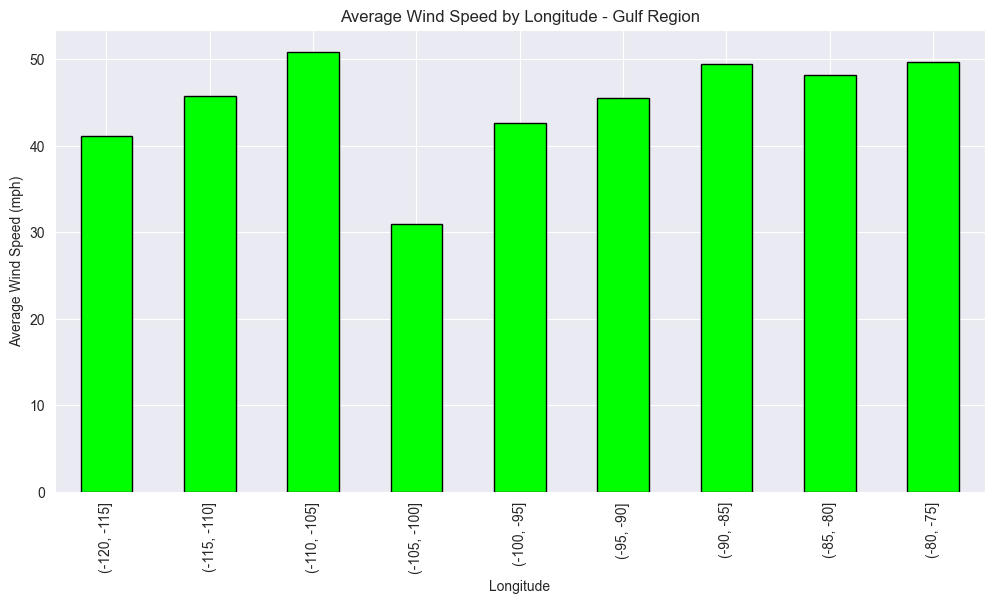

In [16]:
plt.figure(figsize = (12,6)) #Creates a 12x6 figure
binned_data1.plot(kind = 'bar', edgecolor = 'black', color = 'lime') #Makes the figure a bar chart of the binned wind speeds, customizes it

#Adds labels and title
plt.xlabel('Longitude')
plt.ylabel('Average Wind Speed (mph)')
plt.title('Average Wind Speed by Longitude - Gulf Region')

Text(0.5, 1.0, 'Average NRI Hurricane Risk by Popoulation')

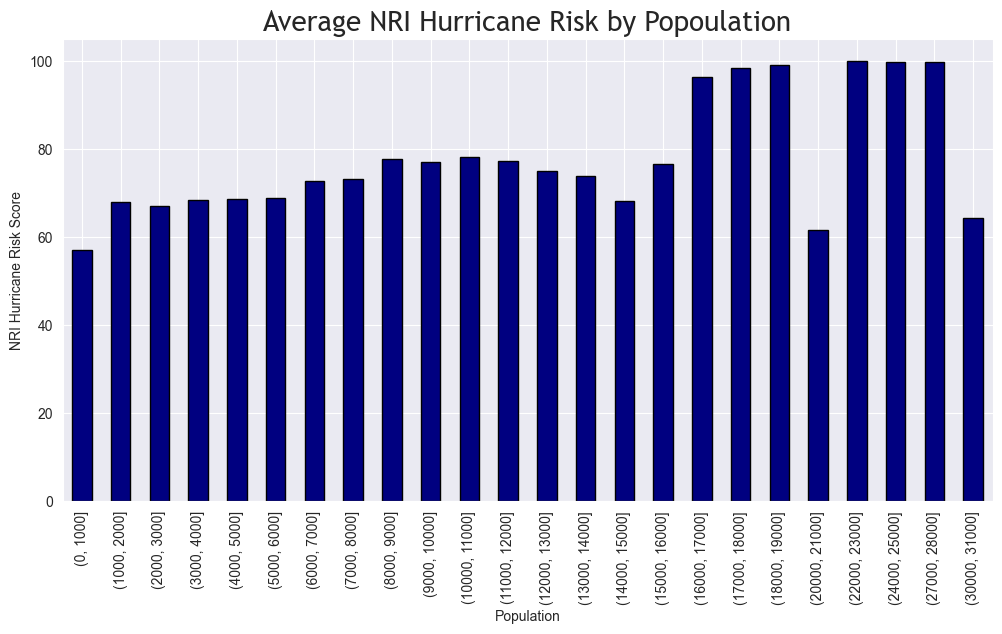

In [17]:
plt.figure(figsize = (12,6)) #Creates a 12x6 figure
binned_data2.plot(kind = 'bar', edgecolor = 'black', color = 'navy') #Makes the figure a bar chart of the binned populations, customizes it

#Adds labels and title
plt.xlabel('Population')
plt.ylabel('NRI Hurricane Risk Score')
plt.title('Average NRI Hurricane Risk by Popoulation', fontname = 'Trebuchet MS', fontsize = 20)

Text(0.5, 1.0, 'Average NRI Hurricane Risk by State')

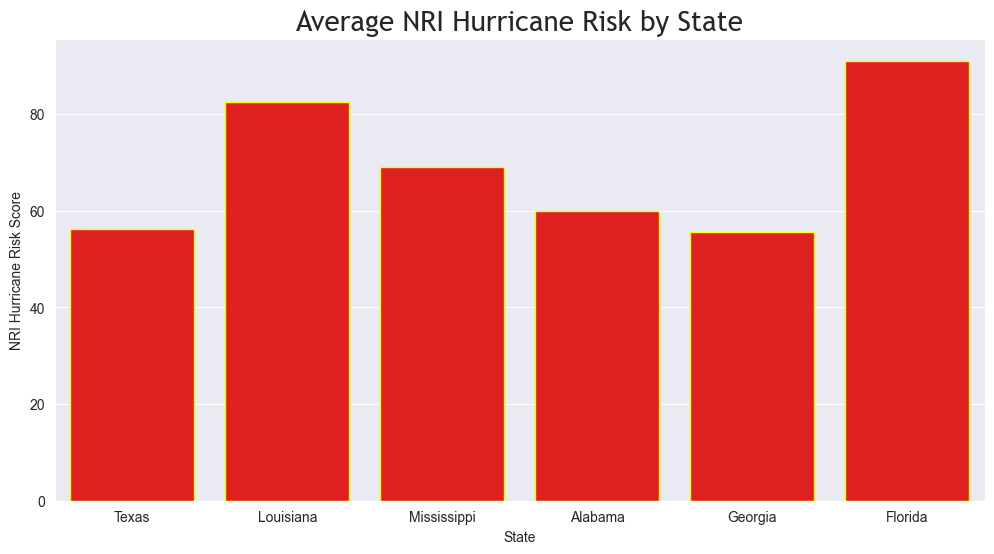

In [18]:
plt.figure(figsize = (12,6))
sns.barplot(binned_data3, edgecolor = 'yellow', color = 'red', order = ['Texas', 'Louisiana', 'Mississippi', 'Alabama', 'Georgia', 'Florida'])
#Adds labels and title
plt.xlabel('State')
plt.ylabel('NRI Hurricane Risk Score')
plt.title('Average NRI Hurricane Risk by State', fontname = 'Trebuchet MS', fontsize = 20)

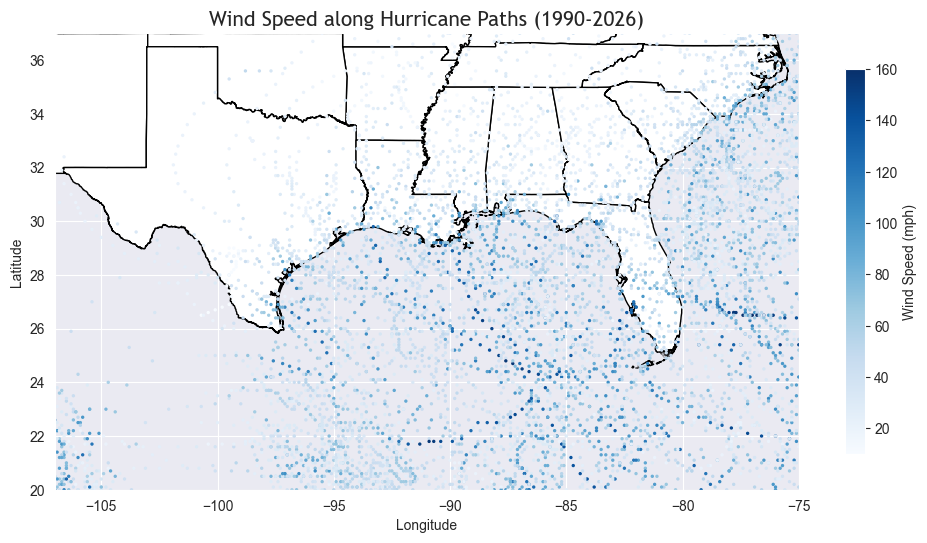

In [19]:
fig, ax = plt.subplots(figsize=(12, 20)) #Creates figure with grid-based layout

states.plot(ax=ax, color='white', edgecolor='black') #Plots US state shapfile

# Plot the joined points, colored by a specific attribute from the CSV
joined.plot(ax=ax, column='USA_WIND', cmap='Blues', markersize=2, legend=True, legend_kwds={'shrink': 0.25, 'label': 'Wind Speed (mph)'})
#Plots the wind speed at each spacial data point from the FEMA dataset

#Sets axis limits by longitude and latitude
ax.set_xlim([-107, -75])  
ax.set_ylim([20, 37])

#Adds title and labels
plt.title('Wind Speed along Hurricane Paths (1990-2026)', fontname = 'Trebuchet MS', fontsize = 15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

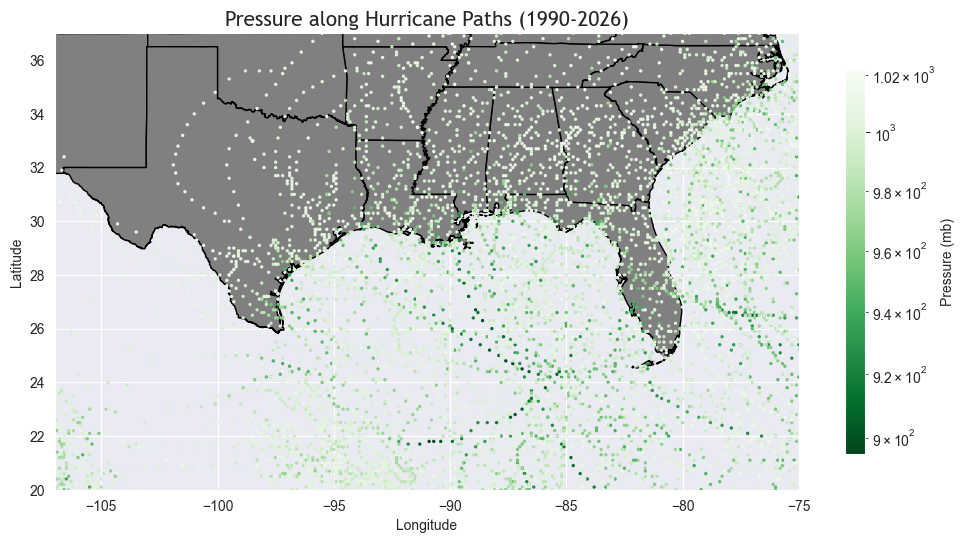

In [20]:
fig, ax = plt.subplots(figsize=(12, 20)) #Creates figure with grid layout

states.plot(ax=ax, color='grey', edgecolor='black') #Plots US state outline shapefile

# Plots the joined points, colored by pressure from the CSV
joined.plot(ax=ax, column='USA_PRES', cmap='Greens_r', markersize=2, legend=True, legend_kwds={'shrink': 0.25, 'label' : 'Pressure (mb)'}, norm = mpc.LogNorm())

#Sets axis limits
ax.set_xlim([-107, -75])  
ax.set_ylim([20, 37])

#Creates title and labels
plt.title('Pressure along Hurricane Paths (1990-2026)', fontname = 'Trebuchet MS', fontsize = 15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

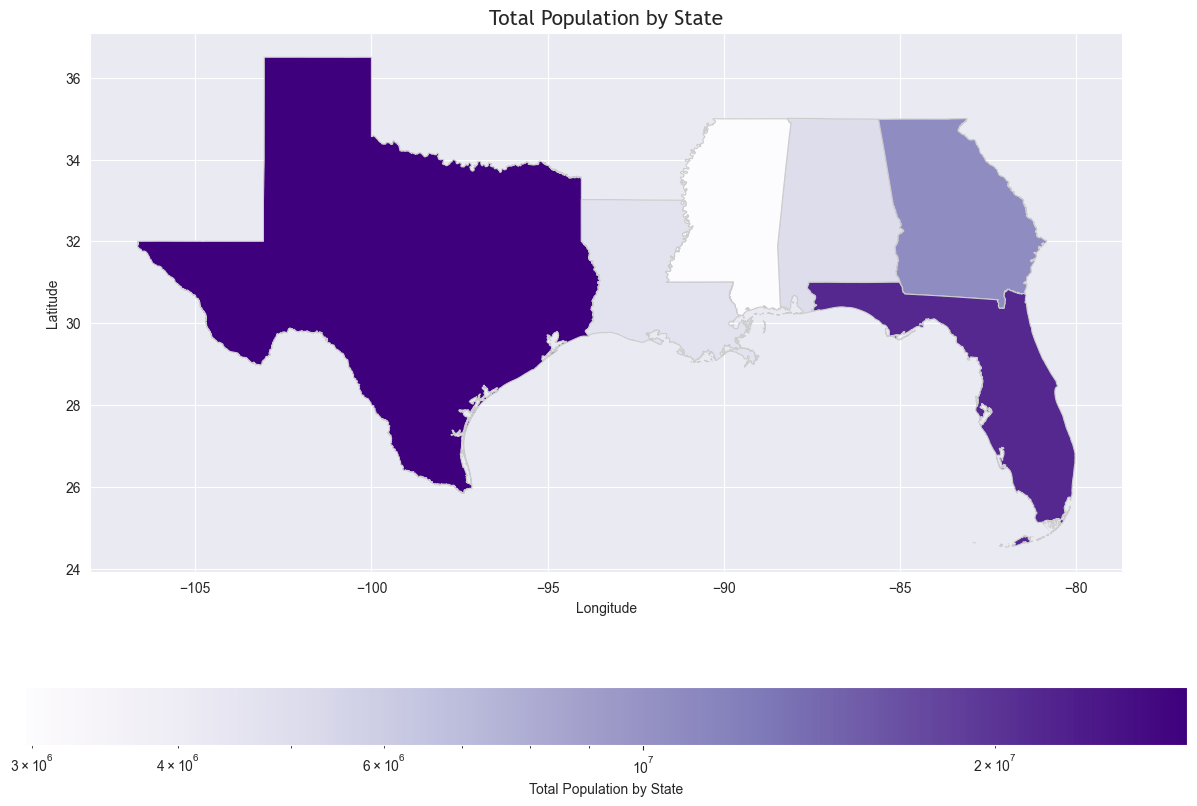

In [21]:
state_pop_data = svi_data.groupby(['STUSPS', 'STATE'])['E_TOTPOP'].sum().reset_index() #Aggregates estimated popoulation from county to state level

complete_pop_data = pd.merge(states, state_pop_data, on='STUSPS', how='left') #Merges state population with state dataframe

complete_pop_data.dropna(subset=['E_TOTPOP'], inplace=True) #Drops rows with NaN values in population column

fig, ax = plt.subplots(1, 1, figsize=(15, 10)) #Creates plot

# Plot states, colored by E_TOTPOP
complete_pop_data.plot(column='E_TOTPOP', cmap='Purples', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
                   legend_kwds={'label': "Total Population by State",'orientation': "horizontal"},
                   norm=mpc.LogNorm()) #Uses LogNorm for better visualization of population, along with other customizations

#Creates title and labels
ax.set_title('Total Population by State', fontname = 'Trebuchet MS', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

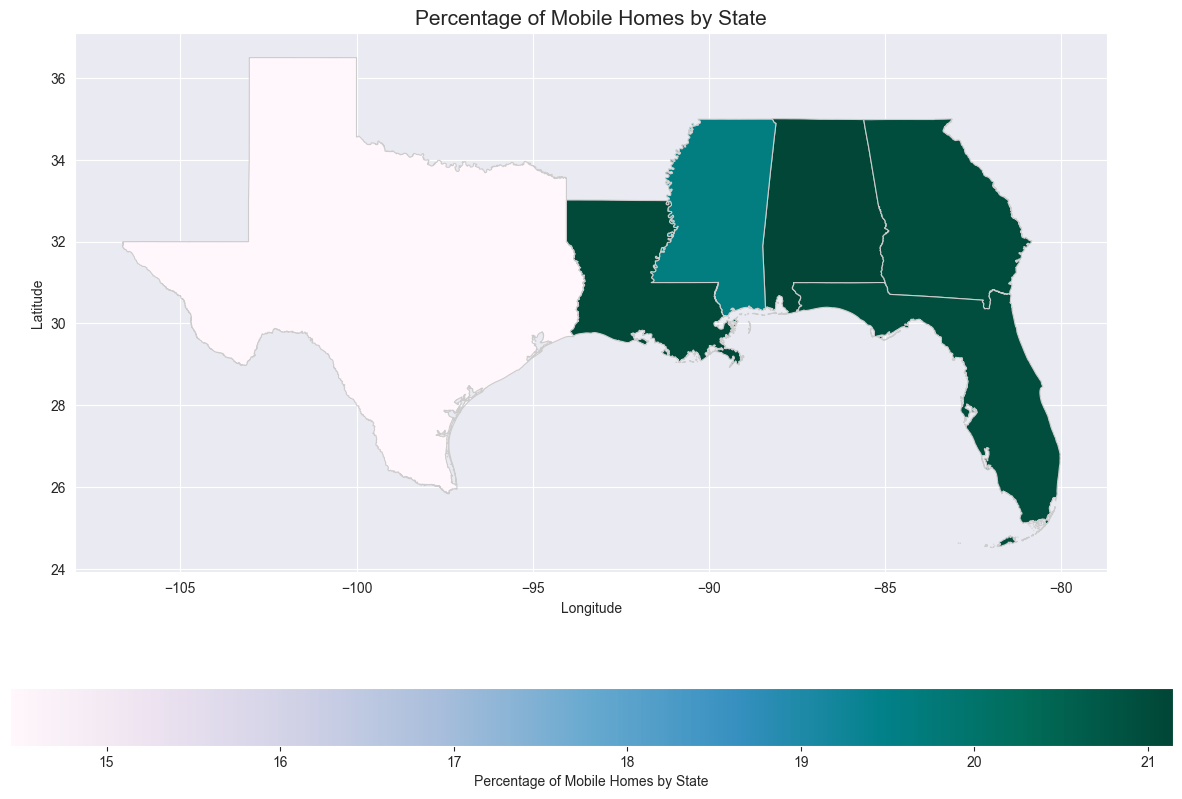

In [22]:
state_mobile_home_data = svi_data.groupby(['STUSPS', 'STATE'])['EP_MOBILE'].mean().reset_index() #Aggregates mobile home percentage by county to state

complete_data_mobile_pct = pd.merge(states, state_mobile_home_data, on='STUSPS', how='left') #Merges mobile home percent with state dataframe

complete_data_mobile_pct.dropna(subset=['EP_MOBILE'], inplace=True) #Drops rows with NaN values in mobile home percent

fig, ax = plt.subplots(1, 1, figsize=(15, 10)) #Creates a figure

#Plots states, colored by EP_MBLHOM
complete_data_mobile_pct.plot(column='EP_MOBILE', cmap='PuBuGn', linewidth=0.8, ax=ax, edgecolor='0.8',legend=True,
                   legend_kwds={'label': "Percentage of Mobile Homes by State", 'orientation': "horizontal"})

#Creates title and labels
ax.set_title('Percentage of Mobile Homes by State', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Text(0.5, 1.0, 'Total Uninsured Population by State')

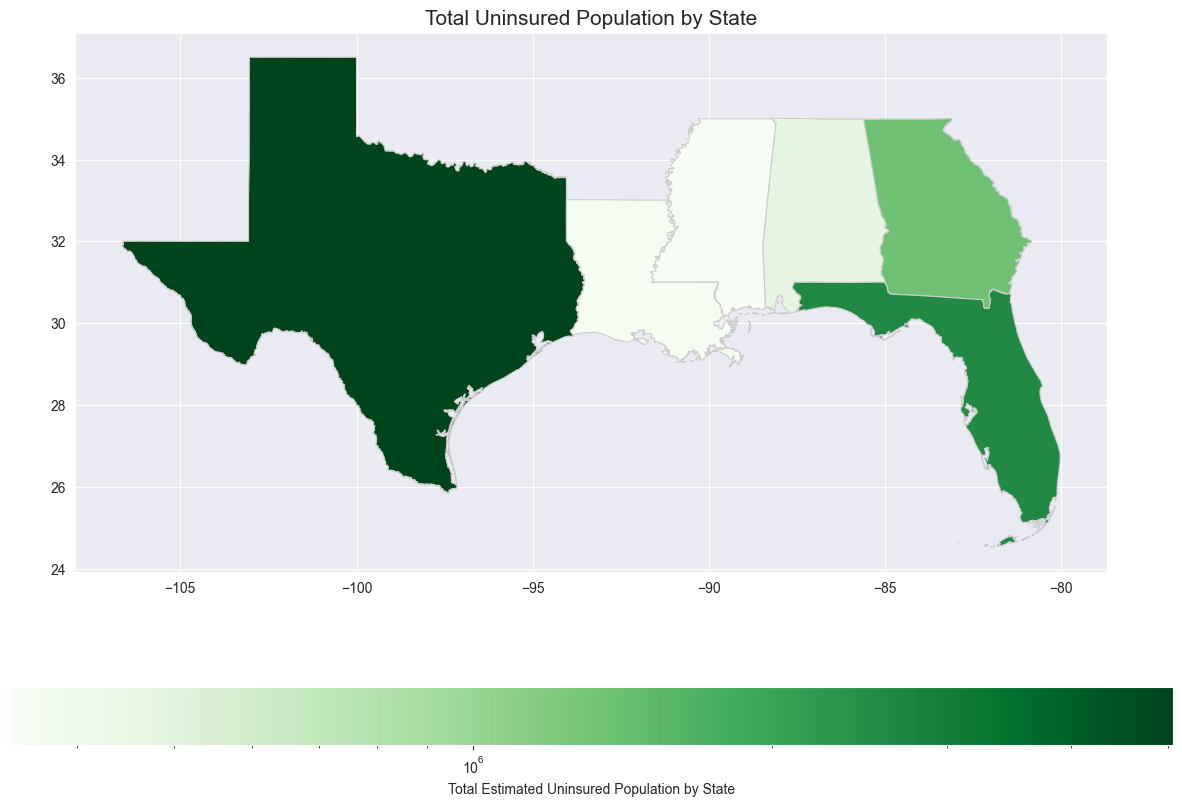

In [23]:
# Aggregate E_TOTPOP from county level to state level
state_pop_data = svi_data.groupby(['STUSPS', 'STATE'])['E_UNINSUR'].sum().reset_index()

# Merge state_pop_data with states GeoDataFrame
complete_data = pd.merge(states, state_pop_data, on='STUSPS', how='left')

# Drop rows with NaN in 'E_TOTPOP' for states not found in SVI data
complete_data.dropna(subset=['E_UNINSUR'], inplace=True)

# Plotting the state populations
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot states, colored by E_TOTPOP
complete_data.plot(column='E_UNINSUR', cmap='Greens', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
                   legend_kwds={'label': "Total Estimated Uninsured Population by State", 'orientation': "horizontal"},
                   norm=mpc.LogNorm()) # Use LogNorm for better visualization of varying populations

ax.set_title('Total Uninsured Population by State', fontsize=15)

Text(0.5, 1.0, 'Total Population 65 and Older by State')

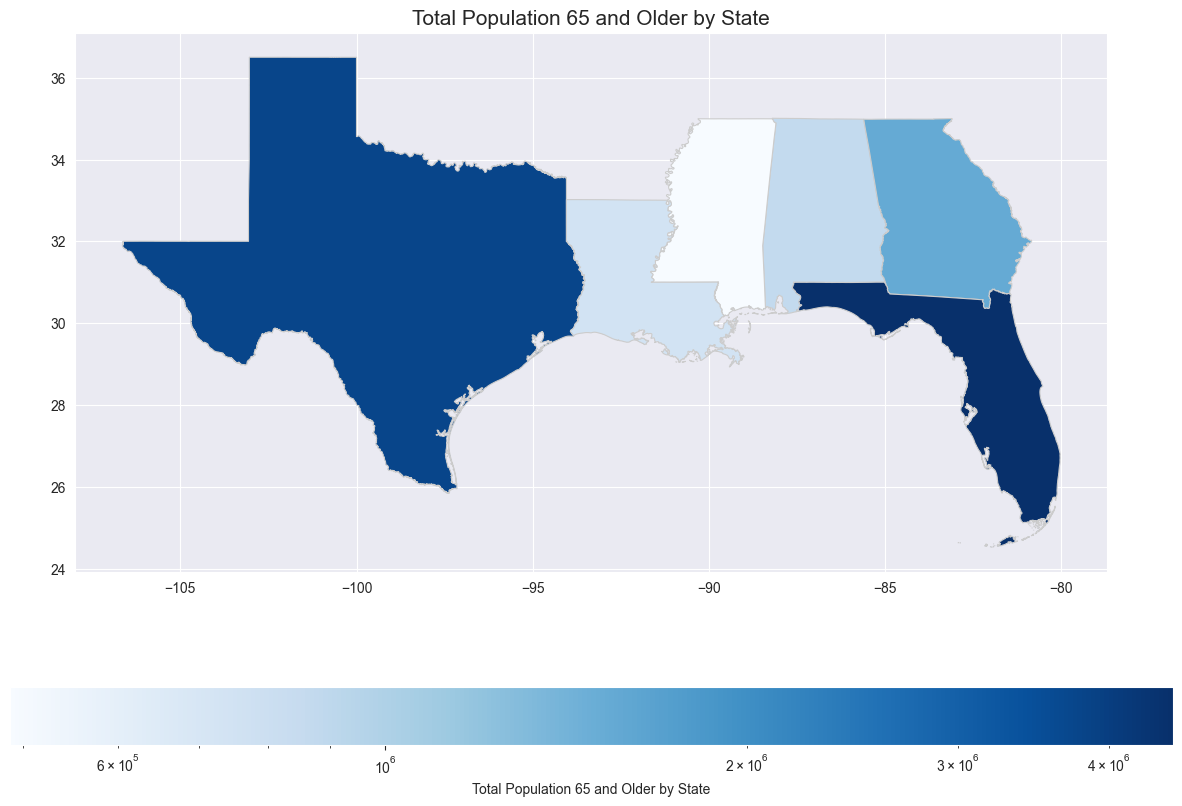

In [24]:
# Aggregate E_TOTPOP from county level to state level
state_pop_data = svi_data.groupby(['STUSPS', 'STATE'])['E_AGE65'].sum().reset_index()

# Merge state_pop_data with states GeoDataFrame
complete_data = pd.merge(states, state_pop_data, on='STUSPS', how='left')

# Drop rows with NaN in 'E_TOTPOP' for states not found in SVI data
complete_data.dropna(subset=['E_AGE65'], inplace=True)

# Plotting the state populations
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot states, colored by E_TOTPOP
complete_data.plot(column='E_AGE65', cmap='Blues', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
                   legend_kwds={'label': "Total Population 65 and Older by State", 'orientation': "horizontal"},
                   norm=mpc.LogNorm()) # Use LogNorm for better visualization of varying populations

ax.set_title('Total Population 65 and Older by State', fontsize=15)

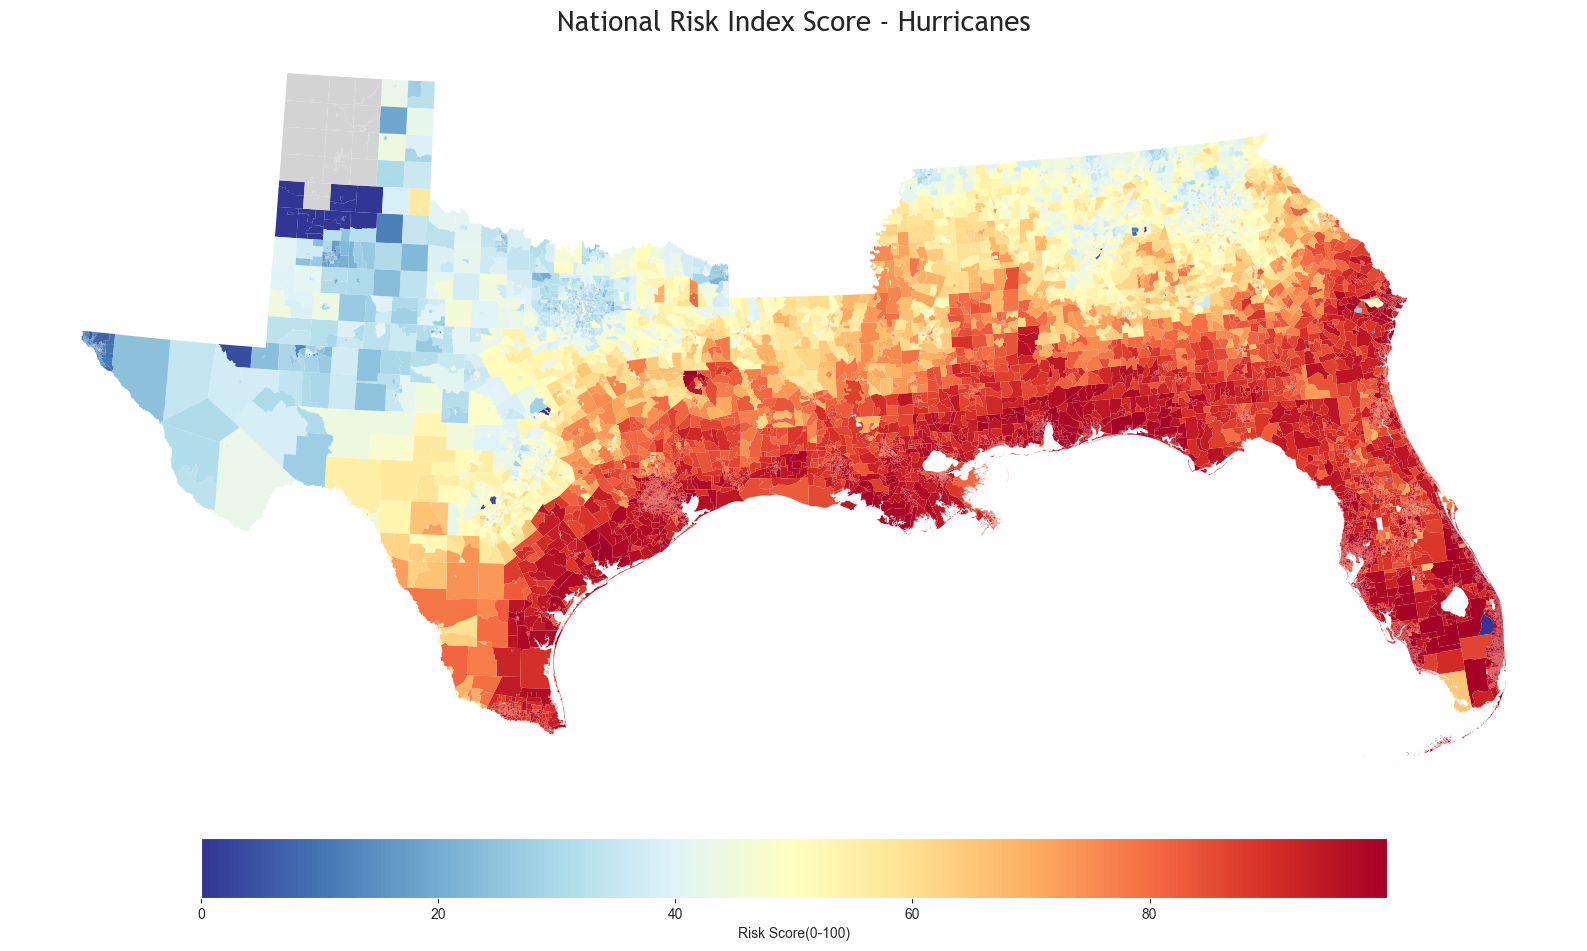

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(18, 10)) #creates plot

#Adds NRI hurricane data
tracts_final.plot(column = 'HRCN_RISKS', ax = ax, legend = True, linewidth = 0.0, cmap = 'RdYlBu_r', legend_kwds = {'label': 'Risk Score(0-100)', 'orientation': 'horizontal', 'shrink':0.67, 'pad':0.05}, missing_kwds = {'color': 'lightgrey', 'label':'No Data'})

ax.set_title('National Risk Index Score - Hurricanes', fontname = 'Trebuchet MS', fontsize = 20) #Adds title
ax.set_axis_off() #Removes axes
plt.tight_layout()

plt.show()

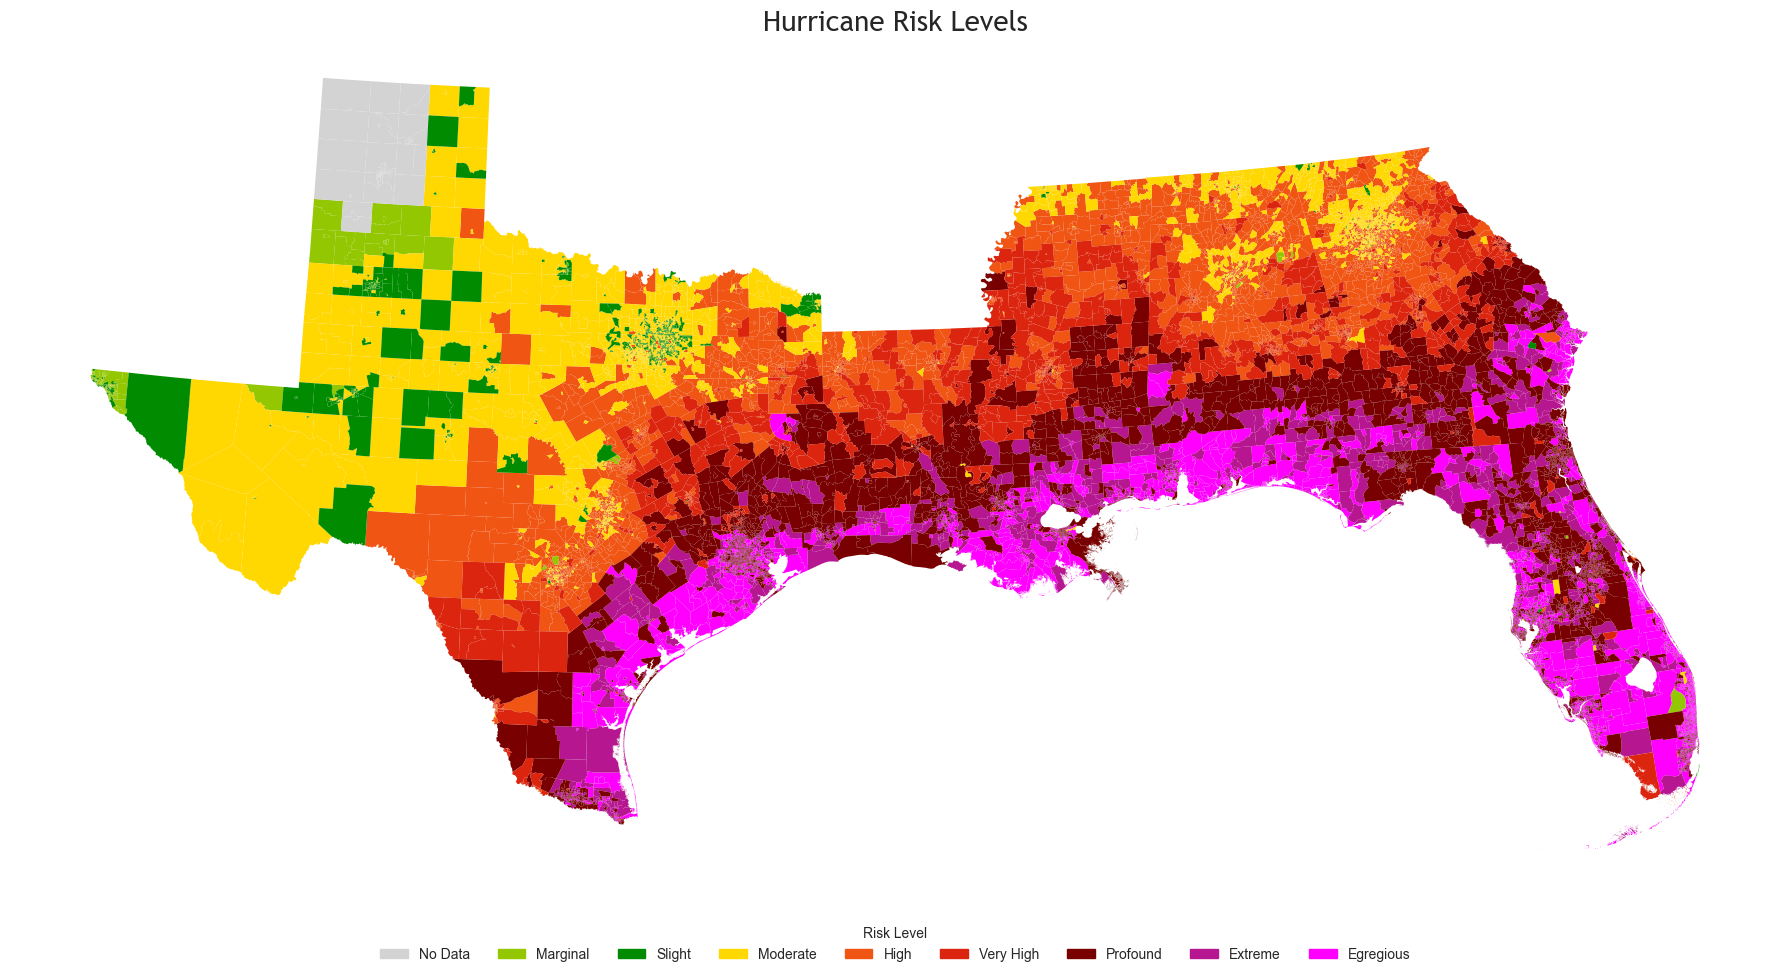

In [26]:
legend_handles = [
    mpatches.Patch(color=risk_palette[level], label=level) 
    for level in risk_order]

fig, ax = plt.subplots(1, 1, figsize=(18, 10)) #creates plot

#Adds column of risks and their associated colors
tracts_final.plot(ax = ax, legend = True, color=tracts_final['plot_color'], linewidth = 0.0, missing_kwds = {'color': 'lightgrey', 'label':'No Data'})

#Customizes legend
ax.legend(
    handles=legend_handles, 
    title="Risk Level",
    loc='lower center',
    ncol=9,
    bbox_to_anchor=(0.5, -0.1),
    frameon=False)

ax.set_title('Hurricane Risk Levels', fontname = 'Trebuchet MS', fontsize = 20) #Adds title
ax.set_axis_off() #Removes axes
plt.tight_layout()

plt.show()